# Dexed dataset audit

Explore the freshly-generated Dexed dataset: link each audio file to its preset parameters and name, extract lightweight audio descriptors, and build a 2D coverage map of the behaviour space.

**Workflow**
1. Setup and paths
2. Explore a single preset (name, params, spectrogram, audio)
3. Link sound to parameters
4. Extract lightweight descriptors on a sample
5. Coverage map (PCA + UMAP)
6. Select and export sounds to download


## 1. Setup and paths

In [1]:
import os, sys, glob, re
# Needed so the Dexed VST3 (libstdc++ 15.2) loads if we ever re-render here
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH','')

# Run this notebook from the spinvae2 project root (adjust if needed)
PROJECT_ROOT = os.path.expanduser('~/projects/spinvae2')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATASET_ROOT = '/data/anasynth_nonbp/longeot/spinvae2_datasets/Dexed'
AUDIO_DIR = os.path.join(DATASET_ROOT, 'Audio')

# MIDI note used at generation time (see config.py: midi_notes = ((56, 75),))
PITCH, VEL = 56, 75

print('Audio dir exists:', os.path.isdir(AUDIO_DIR))
print('Nb wav files   :', len(glob.glob(os.path.join(AUDIO_DIR, '*.wav'))))

Audio dir exists: True
Nb wav files   : 120580


In [2]:
# Load the preset database (names + parameter values for every UID)
from synth.dexed import PresetDfDatabase
from synth.dexed import Dexed  # for param names / cardinalities

db = PresetDfDatabase()
print('Nb presets in DB:', db.nb_presets)
print('Params per preset:', db.nb_params_per_preset)

# Human-readable parameter names (155 of them)
param_types = Dexed.get_param_types(operator_index=True)
print('First param names:', param_types[:6])

Nb presets in DB: 30145
Params per preset: 155
First param names: ['Cutoff', 'Resonance', 'Output', 'MASTER_TUNE_ADJ', 'ALGORITHM', 'FEEDBACK']


In [3]:
# Helpers to go from a wav filename <-> preset UID
def wav_path(uid, variation=0, pitch=PITCH, vel=VEL):
    stem = f"{uid:06d}_pitch{pitch:03d}vel{vel:03d}_var{variation:03d}.wav"
    return os.path.join(AUDIO_DIR, stem)

def uid_from_filename(fname):
    m = re.match(r"(\d{6})_", os.path.basename(fname))
    return int(m.group(1)) if m else None

# All UIDs available in the database
all_uids = list(db.all_preset_UIDs)
print('Example UID:', all_uids[0], '->', wav_path(all_uids[0]))
print('File exists:', os.path.exists(wav_path(all_uids[0])))

Example UID: 0 -> /data/anasynth_nonbp/longeot/spinvae2_datasets/Dexed/Audio/000000_pitch056vel075_var000.wav
File exists: True


## 2. Explore a single preset

Pick a UID, show its name, listen to it, and look at its spectrogram.

UID 0  |  BRITE RDS  (INCONI19)  |  var0
Audio: 64000 samples @ 16000 Hz (4.00s), max=0.325


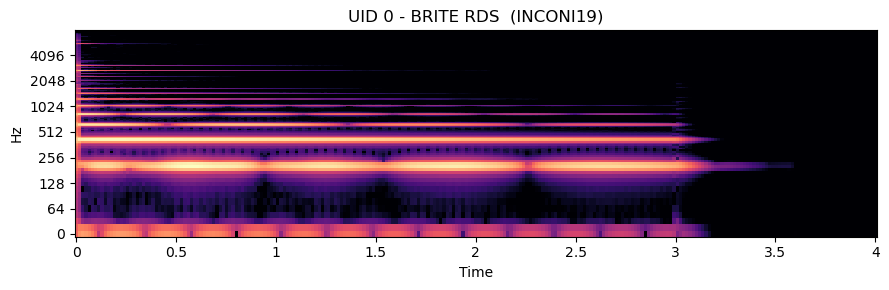

In [4]:
def explore_preset(uid, variation=0):
    name = db.get_preset_name(uid, long_name=True)
    params = db.get_preset_params_values(uid)
    path = wav_path(uid, variation)
    audio, sr = sf.read(path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    print(f"UID {uid}  |  {name}  |  var{variation}")
    print(f"Audio: {len(audio)} samples @ {sr} Hz ({len(audio)/sr:.2f}s), max={np.abs(audio).max():.3f}")
    # spectrogram
    S = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=1024, hop_length=256)), ref=np.max)
    fig, ax = plt.subplots(figsize=(9,3))
    librosa.display.specshow(S, sr=sr, hop_length=256, x_axis='time', y_axis='log', ax=ax)
    ax.set_title(f"UID {uid} - {name}")
    plt.tight_layout(); plt.show()
    display(Audio(audio, rate=sr))
    return params

# Try one
p = explore_preset(all_uids[0])

## 3. Link sound to parameters

Show the parameter vector in a readable way for the current preset.

In [5]:
def show_params(uid):
    params = db.get_preset_params_values(uid)
    df = pd.DataFrame({'idx': range(len(params)), 'name': param_types, 'value': params})
    # Highlight a few global params
    globals_idx = {0:'Cutoff',1:'Reso',2:'Output',4:'Algorithm',5:'Feedback',
                   11:'LFO_KEY_SYNC',12:'LFO_WAVE'}
    print(f"UID {uid}  -  {db.get_preset_name(uid)}")
    for i,label in globals_idx.items():
        print(f"  [{i:3d}] {label:14s} = {params[i]:.3f}")
    # Which operators are ON? (switch params 44,66,88,110,132,154)
    op_switches = [44,66,88,110,132,154]
    ops_on = [k+1 for k,idx in enumerate(op_switches) if params[idx] > 0.5]
    print(f"  Operators ON: {ops_on}")
    return df

df_params = show_params(all_uids[0])
df_params.head(23)  # the 23 global params

UID 0  -  BRITE RDS 
  [  0] Cutoff         = 1.000
  [  1] Reso           = 0.000
  [  2] Output         = 1.000
  [  4] Algorithm      = 0.129
  [  5] Feedback       = 0.857
  [ 11] LFO_KEY_SYNC   = 0.000
  [ 12] LFO_WAVE       = 0.800
  Operators ON: [1, 2, 3, 4, 5, 6]


,idx,name,value
0,0,Cutoff,1.000000
1,1,Resonance,0.000000
2,2,Output,1.000000
3,3,MASTER_TUNE_ADJ,0.500000
4,4,ALGORITHM,0.129032
5,5,FEEDBACK,0.857143
6,6,OSC_KEY_SYNC,0.000000
7,7,LFO_SPEED,0.070707
8,8,LFO_DELAY,0.333333
9,9,LFO_PM_DEPTH,0.000000


## 4. Extract lightweight descriptors on a sample

Compute fast librosa features (spectral centroid, bandwidth, rolloff, flatness, RMS, MFCC means) over a sample of presets (var000 = original presets). Start with 3000, extend later.

In [14]:
def compute_descriptors(audio, sr):
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    # guard against silence
    if np.abs(audio).max() < 1e-6:
        return None
    feats = {}
    S = np.abs(librosa.stft(audio, n_fft=1024, hop_length=256))
    feats['centroid']  = float(np.mean(librosa.feature.spectral_centroid(S=S, sr=sr)))
    feats['bandwidth'] = float(np.mean(librosa.feature.spectral_bandwidth(S=S, sr=sr)))
    feats['rolloff']   = float(np.mean(librosa.feature.spectral_rolloff(S=S, sr=sr)))
    feats['flatness']  = float(np.mean(librosa.feature.spectral_flatness(S=S)))
    feats['rms'] = float(np.mean(librosa.feature.rms(y=audio, frame_length=1024, hop_length=256)))
    feats['zcr']       = float(np.mean(librosa.feature.zero_crossing_rate(audio)))
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    for i in range(13):
        feats[f'mfcc{i}'] = float(np.mean(mfcc[i]))
    return feats

# Sample of UIDs (var000 only)
N_SAMPLE = 3000
rng = np.random.default_rng(0)
sample_uids = list(rng.choice(all_uids, size=min(N_SAMPLE, len(all_uids)), replace=False))
print('Sampling', len(sample_uids), 'presets')

Sampling 3000 presets


In [15]:
from concurrent.futures import ProcessPoolExecutor
import time

def process_uid(uid):
    try:
        audio, sr = sf.read(wav_path(uid, 0))
        f = compute_descriptors(audio, sr)
        if f is None:
            return None
        f['uid'] = int(uid)
        return f
    except Exception as e:
        print(f"Erreur pour uid={uid}: {e}")
        traceback.print_exc()
        return None

t0 = time.time()
rows = []
# Parallel extraction
with ProcessPoolExecutor(max_workers=16) as ex:
    for r in ex.map(process_uid, sample_uids, chunksize=16):
        if r is not None:
            rows.append(r)

print(len(sample_uids))
print(process_uid(sample_uids[0]))
print(rows)

feat_df = pd.DataFrame(rows).set_index('uid')
print(f"Extracted {len(feat_df)} feature rows in {time.time()-t0:.1f}s")
feat_df.head()

3000
{'centroid': 777.6505633862743, 'bandwidth': 660.7901921997158, 'rolloff': 1276.9546812749004, 'flatness': 1.7230029339819602e-05, 'rms': 0.04233114793896675, 'zcr': 0.06284877232142858, 'mfcc0': -559.4923282735042, 'mfcc1': 45.272926830874184, 'mfcc2': -23.207100234585003, 'mfcc3': 7.0444234516265745, 'mfcc4': -5.48818348271634, 'mfcc5': -15.659918174779223, 'mfcc6': -11.568697817215563, 'mfcc7': -15.467513445082846, 'mfcc8': -12.199499624738303, 'mfcc9': -11.730740375423208, 'mfcc10': -14.78679939484427, 'mfcc11': -15.837440694607821, 'mfcc12': -2.4008402879136237, 'uid': 16970}
[{'centroid': 777.6505633862743, 'bandwidth': 660.7901921997158, 'rolloff': 1276.9546812749004, 'flatness': 1.7230029339819602e-05, 'rms': 0.04233114793896675, 'zcr': 0.06284877232142858, 'mfcc0': -559.4923282735042, 'mfcc1': 45.272926830874184, 'mfcc2': -23.207100234585003, 'mfcc3': 7.0444234516265745, 'mfcc4': -5.48818348271634, 'mfcc5': -15.659918174779223, 'mfcc6': -11.568697817215563, 'mfcc7': -15.4

,centroid,bandwidth,rolloff,flatness,rms,zcr,mfcc0,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,mfcc6,mfcc7,mfcc8,mfcc9,mfcc10,mfcc11,mfcc12
uid,,,,,,,,,,,,,,,,,,,
16970,777.650563,660.790192,1276.954681,0.000017,0.042331,0.062849,-559.492328,45.272927,-23.207100,7.044423,-5.488183,-15.659918,-11.568698,-15.467513,-12.199500,-11.730740,-14.786799,-15.837441,-2.400840
3333,309.879780,327.580433,543.700199,0.214278,0.095682,0.025522,-469.449725,144.635846,48.344648,1.267508,-7.905764,-2.453848,-1.998552,-6.244486,-6.244053,-2.286094,-1.585517,-4.257144,-6.078856
75993,1148.942742,1171.861235,2214.454681,0.016066,0.104446,0.092002,-290.336313,73.024160,10.399570,15.448251,1.402349,7.711938,1.122736,8.130090,-3.186068,6.029977,-0.942668,4.501966,-3.403857
54572,308.192722,404.527065,452.751494,0.125432,0.023799,0.022635,-659.526739,33.595435,27.888420,20.697920,13.935145,8.682827,5.143591,2.799915,0.609582,-2.558956,-7.337523,-13.512600,-20.061324
81418,660.493018,665.294543,1135.893924,0.075940,0.020835,0.045321,-576.140124,60.806077,-3.796023,7.074349,-1.596513,-11.281335,-14.627972,-11.420484,-4.969115,-5.576839,-9.030444,-7.414250,-4.346724


## 5. Coverage map (PCA + UMAP)

Standardise features, then project to 2D. PCA is fast and linear; UMAP captures non-linear structure. Colour by spectral centroid (brightness) as a first proxy.

PCA explained variance: 0.40463806225364773


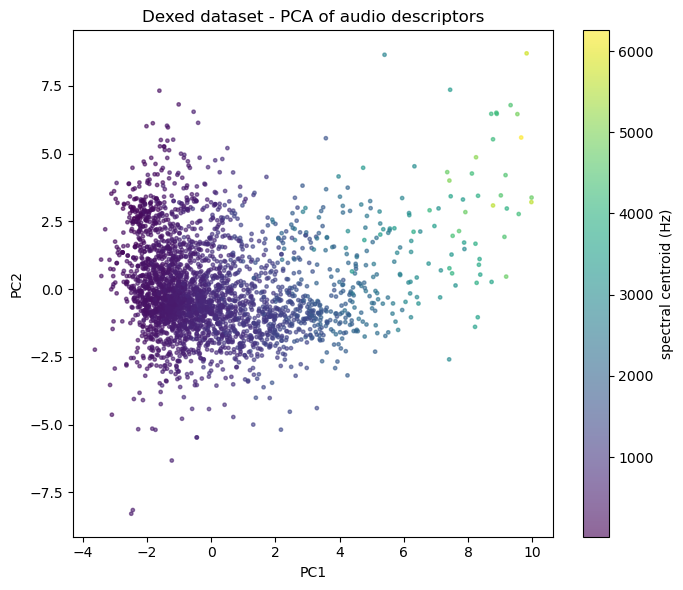

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_cols = [c for c in feat_df.columns]
X = feat_df[feature_cols].values
X = np.nan_to_num(X)
Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Xp = pca.fit_transform(Xs)
print('PCA explained variance:', pca.explained_variance_ratio_[:2].sum())

fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(Xp[:,0], Xp[:,1], c=feat_df['centroid'], s=6, cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='spectral centroid (Hz)')
ax.set_title('Dexed dataset - PCA of audio descriptors')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

2026-07-02 16:16:28.813133: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 16:16:28.858795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783001788.885966 3902601 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783001788.893177 3902601 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-02 16:16:28.920927: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

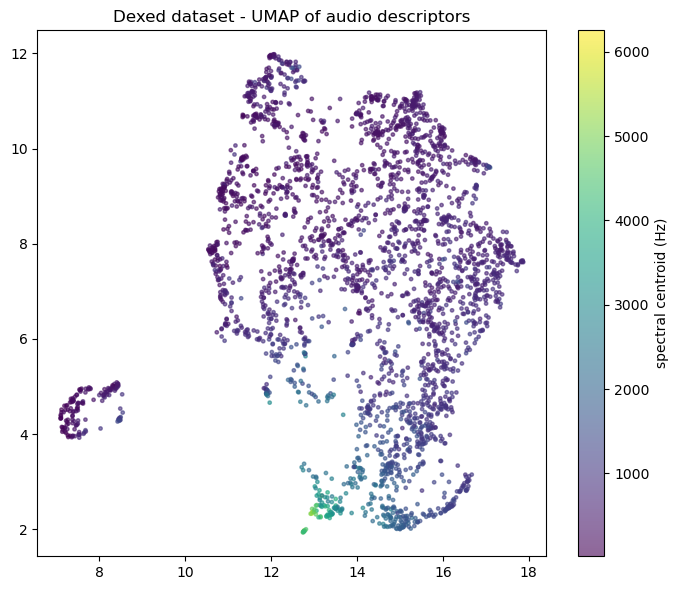

In [17]:
# UMAP (non-linear). pip install umap-learn if missing.
try:
    import umap
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
    Xu = reducer.fit_transform(Xs)
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(Xu[:,0], Xu[:,1], c=feat_df['centroid'], s=6, cmap='viridis', alpha=0.6)
    plt.colorbar(sc, label='spectral centroid (Hz)')
    ax.set_title('Dexed dataset - UMAP of audio descriptors')
    plt.tight_layout(); plt.show()
    feat_df['umap_x'], feat_df['umap_y'] = Xu[:,0], Xu[:,1]
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
feat_df['pca_x'], feat_df['pca_y'] = Xp[:,0], Xp[:,1]

## 6. Select and export sounds to download

Pick UIDs of interest (e.g. from sparse or dense regions of the map) and copy their wav files to a download folder. Then, **from your local machine**, run:

```bash
scp 'gottan:~/to_download/*.wav' ~/dexed_listen/
```

In [19]:
import shutil
DL_DIR = os.path.expanduser('~/projects/to_download')
os.makedirs(DL_DIR, exist_ok=True)

def export_for_download(uids, variation=0):
    copied = []
    for uid in uids:
        src = wav_path(uid, variation)
        if os.path.exists(src):
            name = db.get_preset_name(uid).replace('/', '_').replace(' ', '_')
            dst = os.path.join(DL_DIR, f"{uid:06d}_{name}.wav")
            shutil.copy(src, dst)
            copied.append(dst)
    print(f"Copied {len(copied)} files to {DL_DIR}")
    return copied

# Example: export 10 random presets from the sample
example_uids = list(feat_df.sample(min(10, len(feat_df)), random_state=1).index)
export_for_download(example_uids)

Copied 10 files to /u/anasynth/longeot/projects/to_download


['/u/anasynth/longeot/projects/to_download/030025_VICS1896.H.wav',
 '/u/anasynth/longeot/projects/to_download/001971__DX-PIANO_.wav',
 '/u/anasynth/longeot/projects/to_download/005742_MISC_R-10_.wav',
 '/u/anasynth/longeot/projects/to_download/077933_Ocarina.C_.wav',
 '/u/anasynth/longeot/projects/to_download/077107_FlangBrass.wav',
 '/u/anasynth/longeot/projects/to_download/009272_SYNCLAVIER.wav',
 '/u/anasynth/longeot/projects/to_download/081124_Soft.Lute_.wav',
 '/u/anasynth/longeot/projects/to_download/163020_FUNKY_____.wav',
 '/u/anasynth/longeot/projects/to_download/077637_Greg.Strg_.wav',
 '/u/anasynth/longeot/projects/to_download/071703_Jc.Ch.A___.wav']

### Next steps
- Extend the sample to all 30k presets (remove `N_SAMPLE` cap) once the map looks useful.
- Swap the lightweight librosa descriptors for the perceptual TimbreToolbox + ACTM features used by SpinVAE2's timbre loss, to make the behaviour space Z consistent with the model.
- Overlay reference DX7 presets (known classics) on the map to anchor regions.
- Quantify coverage (convex hull area, grid-cell occupancy, nearest-neighbour distances) to get a baseline to beat with IMGEP.